<div dir="rtl" style="text-align: right;">

# מטלה בלמידת מכונה — זיהוי טקסט AI מול אנושי
## AI vs Human Text Detection

<hr>

<p style="text-align: right;">
<b>סטודנט 1:</b>שלום פריאב' — 327596581
</p>

<p style="text-align: right;">
<b>סטודנט 2:</b> יאיר קרשגייב — 336303755
</p>

<p style="text-align: right;">
<b>Dataset:</b> <a href="https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text" target="_blank">AI Vs Human Text</a>
</p>

<p style="text-align: right;">
<b>סוג מטלה:</b> ניתוח טקסט (NLP)
</p>

<p style="text-align: right;">
<b>סוג למידה:</b> Classification (סיווג)
</p>

<p style="text-align: right;">
<b>אלגוריתם:</b> <u>Logistic Regression</u> (מימוש מאפס)
</p>

</div>

<div dir="rtl" style="text-align: right;">

## שימוש ב-AI / Chatbot במהלך הפרויקט

| מטרה | כלי | תיאור הפרומפט |
|------|-----|---------------|
| הבנת gradient descent עבור Logistic Regression | Claude | "הסבר את נוסחת עדכון המשקלות עם רגולריזציה L2 והמשמעות המתמטית של כל פרמטר" |
| הבנת ההבדל בין fit_transform ל-transform | Claude | "למה על ה-test להשתמש רק ב-transform ולא ב-fit_transform, ומה זה data leakage?" |
| הבנת K-Fold Cross Validation | Claude | "הסבר כיצד K-Fold מחלק את הדאטה ולמה הוא עדיף על חלוקה אחת רגילה" |
| הבנת רגולריזציה L2 והפרמטר C | Claude | "מה המשמעות המתמטית של רגולריזציה L2 ואיך הפרמטר C משפיע על המודל" |
| הבנת imbalanced data | Claude | "מה ההשפעה של דאטה לא מאוזן על מודל סיווג ואיך under-sampling פותר את הבעיה" |
| תכנון ותיעדוף המטלה | Claude | "תן לי צ'קליסט מסודר של כל החלקים במטלה לפי סדר עדיפויות — חובה ובונוסים — עם הערכת זמן לכל שלב" |
| הסבר פונקציית argsort | Claude | "הסבר שורה שורה מה עושה vec.argsort()[-5:][::-1] ומה המשמעות של כל חלק בביטוי" |
| הסבר פונקציית np.clip | Claude | "הסבר מה עושה np.clip ולמה משתמשים בה בתוך פונקציית sigmoid כדי למנוע בעיות חישוביות" |

</div>

<div dir="rtl" style="text-align: right;">

---
# חלק 1 — הקדמה

## תיאור הבעיה וה-Dataset

<p style="text-align: right;">
<b>הבעיה:</b> בעידן של מודלי שפה גדולים (LLMs), קשה יותר ויותר להבחין בין טקסט שנכתב על ידי אדם לבין טקסט שנוצר על ידי AI. מטרת המטלה שלנו היא לבנות <u>מסווג בינארי</u> שיזהה אוטומטית את מקור הטקסט.
</p>

<p style="text-align: right;">
<b>ה-Dataset:</b> הדאטאסט מכיל כ-<b>500,000</b> חיבורים (essays) עם שתי עמודות:
</p>

<ul dir="rtl" style="text-align: right;">
    <li><code>text</code> — הטקסט המלא</li>
    <li><code>generated</code> — תווית בינארית: <b>0</b> (אדם), <b>1</b> (AI).</li>
</ul>

<p style="text-align: right;">
הדאטאסט אינו מאוזן לחלוטין: כ-<b>63%</b> טקסט אנושי לעומת כ-<b>37%</b> טקסט AI, מה שמצריך מאיתנו התייחסות מיוחדת במהלך האימון.
</p>

<p style="text-align: right;">
<b>מדד האיכות:</b> <u>F1-Score</u> על מחלקת ה-AI (generated=1) — מאחר וזו בעיה בינארית שבה זיהוי ה-AI הוא המטרה המרכזית.
</p>

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}, \quad \text{Precision} = \frac{TP}{TP+FP}, \quad \text{Recall} = \frac{TP}{TP+FN}$$

</div>

<div dir="rtl" style="text-align: right;">

## ייבוא ספריות

</div>

In [6]:
# ספריות בסיסיות לחישובים מתמטיים ועבודה עם מערכים
import numpy as np          # חישובים וקטוריים — gradient descent, sigmoid, מטריצות

# ספרייה לעבודה עם טבלאות נתונים
import pandas as pd # טעינת ה-CSV, ניתוח ראשוני של הדאטה, הצגת תוצאות

# ספרייה לויזואליזציה — גרפים ותרשימים
import matplotlib.pyplot as plt  # גרף התכנסות loss, confusion matrix, explainability

# ספרייה לניקוי טקסט
import re                   # הסרת תווים מיוחדים, פיסוק, ניקוי טקסט גולמי

# Feature Engineering — המרת טקסט לוקטורים מספריים
from sklearn.feature_extraction.text import (
    TfidfVectorizer,        # TF-IDF — משקל מילים לפי נדירות בקורפוס
    CountVectorizer         # Bag of Words — ספירת מילים פשוטה
)

# כלי הערכה ואימון 
from sklearn.model_selection import (
    train_test_split,       # פיצול train/test פעם אחת בלבד
    KFold,                  # K-Fold cross validation לבונוס 6א
    ParameterGrid           # יצירת מכפלה קרטזית של פרמטרים לGrid Search
)

# מדדי איכות
from sklearn.metrics import (
    f1_score,               # מדד האיכות הראשי — F1 על מחלקת ה-AI
    classification_report,  # דוח מפורט עם precision, recall, f1 לכל מחלקה
    confusion_matrix        # מטריצת בלבול — TP, FP, TN, FN
)

import warnings
warnings.filterwarnings('ignore')  # הסתרת אזהרות לא קריטיות

print(' ✓')

 ✓


<div dir="rtl" style="text-align: right;">

## טעינת ה-Dataset

<p style="text-align: right;">
טוענים את הדאטה, יוצרים sample מאוזן של 50,000 שורות (25K מכל מחלקה), ומפצלים ל-train/test <b>פעם אחת בלבד</b> — לא מפצלים שוב.
</p>

</div>

In [8]:
df_full = pd.read_csv('AI_Human.csv')#טעינת הדאטהסט המלא

#נציג מידע בסיסי 
print(f'size :{df_full.shape}')
print(f'columns :{list(df_full.columns)}')
print(f'\nClass distribution " ')#התפלגות מחלקות
print(df_full['generated'].value_counts())
print(f'\nClass distribution (%)"')#אחוזונים
print(df_full['generated'].value_counts(normalize = True).round(3)*100)


size :(487235, 2)
columns :['text', 'generated']

Class distribution " 
generated
0.0    305797
1.0    181438
Name: count, dtype: int64

Class distribution (%)"
generated
0.0    62.8
1.0    37.2
Name: proportion, dtype: float64


<div dir="rtl" style="text-align: right;">

### 5 שורות ראשונות — Train

</div>

In [10]:
#נחלץ מהדטא סט באופן אקראי סהכ 50 אלף דגימות - בשביל ריצה מהירה יותר 
df_human = df_full[df_full['generated'] == 0.0].sample(25000 , random_state = 42 ) 
df_ai = df_full[df_full['generated'] == 1.0].sample(25000 , random_state = 42 )

df = pd.concat([df_human , df_ai])#חיבור 2 הdataframes לטבלה אחת 
df = df.sample(frac = 1, random_state = 42 ) #ערבוב של הטבלה 
df = df.reset_index(drop = True )# איפוס אינדקסים 

print(f'Sample size: {df.shape}')
print(f'Class distribution:\n{df["generated"].value_counts()}')

# פיצול train/test חד פעמי 
# sratify מחלק את traning ,  testin בייחס זהה 
train_df , test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['generated'])

print(f'\nTrain size: {len(train_df)}')
print(f'Test size:  {len(test_df)}')



Sample size: (50000, 2)
Class distribution:
generated
1.0    25000
0.0    25000
Name: count, dtype: int64

Train size: 40000
Test size:  10000


<div dir="rtl" style="text-align: right;">

### 5 שורות ראשונות — Test

</div>

In [12]:
# הדפסת 5 השורות הראשונות מכל דאטא

print('=== Tarin set — first 5 rows ===')
display(train_df.head())
print('\n=== Test set — first 5 rows ===')
display(test_df.head())


=== Tarin set — first 5 rows ===


,text,generated
47765,I agree with the principal's decision that all...,1.0
20293,Many schools assign summer projects as a way t...,0.0
43100,Studying a plane called Venus is worthy pursui...,0.0
19550,I don't believe the students would benefit fro...,0.0
13739,"Dear Principal,\n\nAs we all know any people i...",0.0



=== Test set — first 5 rows ===


,text,generated
18985,Our system of driving has been implemented for...,0.0
39931,You Should be a Seagoing Cowboy. What are Seag...,0.0
30269,"Hey there! So, you want me to write about the...",1.0
42417,"Dear principal,\n\nI really think of should go...",0.0
33651,"390,000 injuries occur each year from accident...",0.0


<div dir="rtl" style="text-align: right;">

---
# חלק 2 — Feature Engineering

<p style="text-align: right;">
מודלי למידת מכונה לא יכולים לעבוד ישירות עם טקסט גולמי — הם דורשים וקטורים מספריים. תהליך ה-<b>Feature Engineering</b> הופך טקסט לוקטור מספרי שמייצג אותו. נתנסה בשתי שיטות:
</p>

| שיטה | רעיון | יתרון | חיסרון |
|------|--------|--------|--------|
| Bag of Words | ספירת מילים | פשוט ומהיר | לא מביא בחשבון נדירות |
| TF-IDF | ספירה × נדירות | מדויק יותר | קצת יותר מורכב |

## עיבוד מקדים — ניקוי טקסט

<p style="text-align: right;">
לפני שנבנה את ה-features, נבצע ניקוי בסיסי של הטקסט:
</p>

<ul dir="rtl" style="text-align: right;">
    <li>המרה ל-lowercase (אותיות קטנות).</li>
    <li>הסרת תווים מיוחדים וסימני פיסוק.</li>
    <li>הסרת רווחים מיותרים.</li>
</ul>

</div>

In [14]:
# פונקציית ניקוי טקסט, נכתוב פונקציה אחת שמנקה את הטקסט מכל האלמנטים המיותרים 
def clean_text(text):
    #   המרה לאותיות קטנות
    text = text.lower()

    # הסרת תווים מיוחדים וסימני פיסוק
    # שומרים רק אותיות באנגלית ורווחים
    text = re.sub(r'[^a-z\s]', '', text)

    #   הסרת רווחים מיותרים
    text = re.sub(r'\s+', ' ', text).strip()

    return text

#ישום הפונקציה 
train_df = train_df.copy()
test_df  = test_df.copy()

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

#נציג חלק משורות הטבלאות כדי לראות שיש באמת ניקוי של הטקסט 
print('=== Tarin set — first 5 rows ===')
display(train_df.head())
print('\n=== Test set — first 5 rows ===')
display(test_df.head())



=== Tarin set — first 5 rows ===


,text,generated,clean_text
47765,I agree with the principal's decision that all...,1.0,i agree with the principals decision that all ...
20293,Many schools assign summer projects as a way t...,0.0,many schools assign summer projects as a way t...
43100,Studying a plane called Venus is worthy pursui...,0.0,studying a plane called venus is worthy pursui...
19550,I don't believe the students would benefit fro...,0.0,i dont believe the students would benefit from...
13739,"Dear Principal,\n\nAs we all know any people i...",0.0,dear principal as we all know any people in th...



=== Test set — first 5 rows ===


,text,generated,clean_text
18985,Our system of driving has been implemented for...,0.0,our system of driving has been implemented for...
39931,You Should be a Seagoing Cowboy. What are Seag...,0.0,you should be a seagoing cowboy what are seago...
30269,"Hey there! So, you want me to write about the...",1.0,hey there so you want me to write about the pr...
42417,"Dear principal,\n\nI really think of should go...",0.0,dear principal i really think of should go wit...
33651,"390,000 injuries occur each year from accident...",0.0,injuries occur each year from accidents caused...


<div dir="rtl" style="text-align: right;">

## 🎒 Bag of Words (BoW)

<p style="text-align: right;">
<b>הרעיון:</b> כל מסמך $d$ מיוצג על ידי וקטור $\mathbf{v} \in \mathbb{R}^{|V|}$, כאשר $|V|$ הוא גודל ה-vocabulary. אנחנו מתייחסים לטקסט כאל "שק של מילים" ללא חשיבות לסדר המקורי:
</p>

$$v_j = \text{count}(w_j, d) = \text{number of times word } w_j \text{ appears in document } d$$
<p style="text-align: right;">
<b>יתרונות:</b> פשוט ומהיר. <b>חסרונות:</b> לא מביא בחשבון עד כמה מילה נדירה בקורפוס — מילה כמו "the" מקבלת ספירה גבוהה אך אינה אינפורמטיבית.
</p>

</div>

In [16]:
#bow= bag of word , מילון שהוגדר לגודל 10000
bow_vectorizer = CountVectorizer(max_features=10000)
# fit_transform = עושה ווקטור לכל המילים וסופר כמות הופעות לכל מילה 
X_train_bow = bow_vectorizer.fit_transform(train_df['clean_text'])
# כאן נהפוך מילים מהמילון ב test לווקטורים
X_test_bow  = bow_vectorizer.transform(test_df['clean_text'])

print(f'BoW matrix shape (train): {X_train_bow.shape}')
print(f'BoW matrix shape (test):  {X_test_bow.shape}')


BoW matrix shape (train): (40000, 10000)
BoW matrix shape (test):  (10000, 10000)


<div dir="rtl" style="text-align: right;">

### הצגת BoW על 2-3 דוגמאות מה-train וה-test

</div>

In [18]:
def show_bow_examples(df_split, X_split, split_name, n=3):
    print(f'=== BoW examples ({split_name}) ===\n')
    for i in range(n):
        row       = df_split.iloc[i]#עובר על שוורת 
        label     = 'AI' if row['generated'] == 1.0 else 'Human'
        vec       = X_split[i].toarray()[0]#לקיחת שורה מספר i מהמטריצה הדלילה והפיכתה למערך המייצג ווקטור
        top_idx   = vec.argsort()[-5:][::-1]#ממינים את האינדקסים של הווקטור לפי מספר ההפעות 
        top_words = [(bow_vectorizer.get_feature_names_out()[j], int(vec[j])) for j in top_idx]
        print(f'[{label}] "{row["clean_text"][:100]}..."')
        print(f'Top words: {top_words}\n')

# הפעלה על train ו-test
show_bow_examples(train_df, X_train_bow, 'Train')
show_bow_examples(test_df,  X_test_bow,  'Test')

=== BoW examples (Train) ===

[AI] "i agree with the principals decision that all students should participate in at least one extracurri..."
Top words: [('students', 10), ('in', 10), ('to', 10), ('and', 9), ('or', 5)]

[Human] "many schools assign summer projects as a way to ensure that students continue learning throughout su..."
Top words: [('to', 71), ('students', 38), ('they', 30), ('projects', 25), ('the', 24)]

[Human] "studying a plane called venus is worthy pursuit buq iq is dangerous as we have seen in the paragraph..."
Top words: [('is', 18), ('the', 15), ('iq', 11), ('to', 11), ('and', 11)]

=== BoW examples (Test) ===

[Human] "our system of driving has been implemented for an along time now driverless cars would be a huge lea..."
Top words: [('the', 18), ('and', 14), ('wiaa', 13), ('in', 11), ('to', 11)]

[Human] "you should be a seagoing cowboy what are seagoing cowboyr seagoing cowboyr are the people that take ..."
Top words: [('seagoing', 11), ('you', 7), ('of', 7), ('c

<div dir="rtl" style="text-align: right;">

## 📊 TF-IDF — Term Frequency × Inverse Document Frequency

<p style="text-align: right;">
<b>הרעיון:</b> מילה שמופיעה הרבה ב<u>מסמך ספציפי</u> אבל נדירה ב<u>כלל המסמכים</u> מקבלת ציון גבוה.
</p>

<p style="text-align: right;">
<b>שלב 1 — TF (Term Frequency):</b> תדירות המילה $t$ במסמך $d$:
</p>

$$\text{TF}(t, d) = \frac{\text{count}(t, d)}{\text{מספר המילים ב-}d}$$

<p style="text-align: right;">
<b>שלב 2 — IDF (Inverse Document Frequency):</b> עד כמה המילה נדירה בקורפוס:
</p>

$$\text{IDF}(t) = \log\left(\frac{N}{\text{df}(t)}\right)$$

<p style="text-align: right;">
כאשר $N$ = מספר המסמכים הכולל, $\text{df}(t)$ = מספר המסמכים שמכילים את $t$.
</p>

<p style="text-align: right;">
<b>שלב 3 — TF-IDF הסופי:</b>
</p>

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

</div>

In [20]:
# ngram_range=(1,2) — לומד גם מילים בודדות וגם זוגות מילים
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
# fit_transform = עושה ווקטור לכל המילים וסופר כמות הופעות לכל מילה 
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['clean_text'])
# כאן נהפוך מילים מהמילון ב test לווקטורים
X_test_tfidf  = tfidf_vectorizer.transform(test_df['clean_text'])

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test):  {X_test_tfidf.shape}')


TF-IDF matrix shape (train): (40000, 10000)
TF-IDF matrix shape (test):  (10000, 10000)


<div dir="rtl" style="text-align: right;">

### הצגת TF-IDF על 2-3 דוגמאות מה-train וה-test

</div>

In [22]:
def show_tfidf_examples(df_split, X_split, vectorizer, split_name, n=3):
    print(f'=== TF-IDF examples ({split_name}) ===\n')
    for i in range(n):
        row       = df_split.iloc[i]#מעבר על שורות 
        label     = 'AI' if row['generated'] == 1.0 else 'Human'
        vec       = X_split[i].toarray()[0]#לקיחת שורה מספר i מהמטריצה הדלילה והפיכתה למערך המייצג ווקטור
        top_idx   = vec.argsort()[-5:][::-1]#ממינים את האינדקסים של הווקטור לפי מספר ההפעות 
        top_words = [(vectorizer.get_feature_names_out()[j], round(float(vec[j]), 3)) for j in top_idx]
        print(f'[{label}] "{row["clean_text"][:100]}..."')
        print(f'Top TF-IDF words: {top_words}\n')

# הפעלה על train ו-test
show_tfidf_examples(train_df, X_train_tfidf, tfidf_vectorizer, 'Train')
show_tfidf_examples(test_df,  X_test_tfidf,  tfidf_vectorizer, 'Test')

=== TF-IDF examples (Train) ===

[AI] "i agree with the principals decision that all students should participate in at least one extracurri..."
Top TF-IDF words: [('students', 0.252), ('extracurricular', 0.225), ('extracurricular activity', 0.167), ('the principals', 0.142), ('extracurriculars', 0.134)]

[Human] "many schools assign summer projects as a way to ensure that students continue learning throughout su..."
Top TF-IDF words: [('projects', 0.364), ('students', 0.308), ('to', 0.269), ('designed projects', 0.208), ('learning', 0.19)]

[Human] "studying a plane called venus is worthy pursuit buq iq is dangerous as we have seen in the paragraph..."
Top TF-IDF words: [('iq', 0.598), ('venus', 0.232), ('plane', 0.214), ('is', 0.162), ('land on', 0.142)]

=== TF-IDF examples (Test) ===

[Human] "our system of driving has been implemented for an along time now driverless cars would be a huge lea..."
Top TF-IDF words: [('cars', 0.291), ('the', 0.195), ('implementation', 0.173), ('and', 

<div dir="rtl" style="text-align: right;">

---
# חלק 3 — מימוש Logistic Regression מאפס

## הרעיון המתמטי

<p style="text-align: right;">
Logistic Regression הוא אלגוריתם <b>סיווג</b> (למרות השם) שמחשב <b>הסתברות</b> שדוגמה שייכת למחלקה 1. במקרה שלנו — מה הסיכוי שהטקסט נכתב על ידי AI.
</p>

### שלב 1 — Linear Combination

<p style="text-align: right;">
לכל טקסט מחשבים <b>ציון לינארי</b> — סכום משוקלל של כל המילים שבו. כל מילה $x_j$ מקבלת משקל $w_j$ שנלמד באימון:
</p>

$$z = \mathbf{w}^T \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \cdots + w_D x_D + b$$

<p style="text-align: right;">
כאשר $\mathbf{x}$ הוא וקטור ה-BoW של הטקסט (10,000 ערכים — ספירת הופעות של כל מילה), $\mathbf{w}$ הוא וקטור המשקלות שנלמד באימון (מילה שמאפיינת AI תקבל משקל גבוה), ו-$b$ הוא היסט (bias) שמאפשר למודל "לזוז" מהראשית.
</p>

### שלב 2 — פונקציית Sigmoid

<p style="text-align: right;">
הציון הלינארי $z$ יכול להיות כל מספר — שלילי, חיובי, גדול או קטן. פונקציית ה-Sigmoid "כובשת" אותו לטווח $(0,1)$ והופכת אותו <b>להסתברות</b>:
</p>

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

<ul dir="rtl" style="text-align: right;">
    <li>אם $z \gg 0$ ← $\hat{y} \to 1$ (כמעט בטוח AI)</li>
    <li>אם $z \ll 0$ ← $\hat{y} \to 0$ (כמעט בטוח Human)</li>
    <li>אם $z = 0$ ← $\hat{y} = 0.5$ (ספק מוחלט)</li>
</ul>

<p style="text-align: right;">
<b>חשוב:</b> בקוד משתמשים ב-<code>np.clip(z, -20, 20)</code> לפני החישוב — כדי למנוע overflow מתמטי. ערכים גדולים מאוד של $z$ גורמים ל-$e^{-z}$ להתפוצץ לאינסוף ולשבור את החישוב.
</p>

### שלב 3 — פונקציית Loss

<p style="text-align: right;">
כדי לאמן את המודל צריך למדוד <b>כמה הוא טועה</b>. משתמשים ב-Binary Cross Entropy עם רגולריזציה L2:
</p>

$$L(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right] + \frac{1}{2C}\|\mathbf{w}\|^2$$

<ul dir="rtl" style="text-align: right;">
    <li><b>האיבר הראשון — Binary Cross Entropy:</b> מודד את המרחק בין החיזוי לאמת. מעניש בחומרה על ביטחון מופרז בניחוש שגוי — למשל אם חיזינו 0.99 AI אבל זה היה Human, ה-Loss יהיה גבוה מאוד.</li>
    <li><b>האיבר השני — רגולריזציה L2:</b> $\frac{1}{2C}\|\mathbf{w}\|^2 = \frac{1}{2C}(w_1^2 + w_2^2 + \cdots + w_M^2)$ — עונש על משקלים גדולים. מונע מהמודל לסמוך על מילה אחת בלבד ולהתמקצן יתר על המידה על ה-train.</li>
    <li>$C$ גדול (10) → $\frac{1}{2C}$ קטן → עונש קטן → משקלים יכולים לגדול → מודל גמיש יותר. <b>זה מה שעבד הכי טוב אצלנו.</b></li>
    <li>$C$ קטן (0.1) → $\frac{1}{2C}$ גדול → עונש גדול → משקלים נשארים קטנים → מודל פשוט ומוגבל.</li>
</ul>

### שלב 4 — Gradient Descent

<p style="text-align: right;">
כדי למזער את ה-Loss מחשבים את <b>הגרדיאנט</b> — הנגזרת של ה-Loss לגבי כל משקל. הגרדיאנט מראה לאיזה כיוון ה-Loss עולה, ואנחנו הולכים בכיוון ההפוך:
</p>

$$\nabla_{\mathbf{w}} L = \underbrace{\frac{1}{N} X^T (\hat{\mathbf{y}} - \mathbf{y})}_{\text{תרומת ה-BCE}} + \underbrace{\frac{1}{C}\mathbf{w}}_{\text{תרומת L2}}$$

<p style="text-align: right;">
</p>
<p style="text-align: right;"> מילה שהופיעה הרבה במסמכים שטעינו בהם → גרדיאנט גדול → המשקל שלה ישתנה הרבה
   </p> 
   <b>פירוט הפרמטרים:</b>
<ul dir="rtl" style="text-align: right;">
    <li>$\hat{\mathbf{y}} - \mathbf{y}$ — וקטור השגיאות: ההפרש בין החיזוי לאמת לכל מסמך.</li>
    <li>$X^T$ — טרנספוז של מטריצת ה-features. כפל $X^T \cdot \text{error}$ מחשב לכל מילה כמה היא "אחראית" לשגיאה הכוללת.</li>
    <li>$\frac{1}{N}$ — מחלקים בN כדי לקבל ממוצע ולא סכום — אחרת דאטה גדול ייתן גרדיאנטים ענקיים.</li>
    <li>$\frac{1}{C}\mathbf{w}$ — דחיפה קבועה של כל משקל לכיוון האפס בכל איטרציה. C גדול = דחיפה חלשה.</li>
</ul>


### שלב 5 — סיווג

<p style="text-align: right;">
לאחר קבלת ההסתברות $\hat{y}$, מחילים <b>סף החלטה</b> של 0.5:
</p>

$$\hat{y}_{\text{class}} = \begin{cases} 1 & \text{if } \hat{y} \geq 0.5 \text{ (AI)} \\ 0 & \text{if } \hat{y} < 0.5 \text{ (Human)} \end{cases}$$

## מימוש המחלקה

</div>

In [24]:
import scipy.sparse as sp

class LogisticRegressionScratch:
    """
    מימוש מאפס של Logistic Regression עם Gradient Descent.
    האלגוריתם לומד למצוא את המשקלות האופטימליות שממקסמות
    את הסיכוי לסווג נכון כל טקסט כ-AI או אנושי.
    """

    def __init__(self, C=1.0, learning_rate=0.01, max_iter=1000, tol=1e-4):
        # אתחול הגדרות המודל: עוצמת רגולריזציה, קצב למידה, מקסימום סיבובים וסף עצירה
        self.C             = C
        self.learning_rate = learning_rate
        self.max_iter      = max_iter
        self.tol           = tol
        # הגדרת המשקלים וההטיה כריק — ערכיהם ייקבעו וילמדו רק בשלב האימון (fit)
        self.weights       = None
        self.bias          = None
        # מערך ריק שישמור את ערך ה-Loss של כל איטרציה לצורך מעקב אחר ההתכנסות
        self.loss_history  = []

    def sigmoid(self, z):
        # חסימת ערכי הציון הליניארי בטווח בטוח כדי למנוע קריסה מתמטית (overflow)
        z_clipped = np.clip(z, -20, 20)
        # כיווץ הציון לעקומת S שמחזירה הסתברות בין 0 ל-1
        return 1 / (1 + np.exp(-z_clipped))

    def compute_loss(self, y, y_hat):
        # חישוב כמות השורות לצורך מציאת ממוצע הטעות
        N   = len(y)
        eps = 1e-15  # מונע חישוב log(0) שאינו מוגדר מתמטית
        y_hat = np.clip(y_hat, eps, 1 - eps)

        # Binary Cross Entropy — מעניש בחומרה על ביטחון מופרז בניחוש שגוי
        loss_bce = -(1 / N) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        # רגולריזציה L2 — קנס על משקלים קיצוניים, מונע Overfitting
        loss_reg = (1 / (2 * self.C)) * np.sum(self.weights ** 2)

        # Loss כולל = שגיאת חיזוי + עונש על משקלים גדולים
        return loss_bce + loss_reg

    def fit(self, X, y):
        # חילוץ כמות הדוגמאות (N) וכמות המילים במילון (M)
        N, M = X.shape#x הוא מטריצת המאפיינים כלומר תוצאות ה bag of word 

        # אתחול אקראי קטן — מונע את בעיית ה-zero gradient
        np.random.seed(42)
        self.weights= np.random.randn(M) * 0.01#יוצר ווקטור משקלים בגודל m
        self.bias= 0.0
        self.loss_history = []

        for i in range(self.max_iter):

            # שלב 1 — Forward pass: ציון ליניארי → הסתברות דרך sigmoid
            z = X.dot(self.weights) + self.bias
            y_hat = self.sigmoid(z)

            # שלב 2 — חישוב Loss ושמירתו לגרף ההתכנסות
            loss = self.compute_loss(y, y_hat)
            self.loss_history.append(loss)

            # שלב 3 — תנאי עצירה: אם השיפור זניח — המודל התכנס
            if i > 0 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tol:
                print(f'Converged at iteration {i} | Loss: {loss:.6f}')
                break

            # שלב 4 — חישוב ההפרש בין החיזוי לאמת
            error = y_hat - y

            # שלב 5 — גרדיאנטים: כמה ובאיזה כיוון לתקן כל משקל
            dw = (1 / N) * X.T.dot(error) + (self.weights / self.C)  #כמה לשנות כל משקל
            db = (1 / N) * np.sum(error)#כמה לשנות כל bais

            # שלב 6 — עדכון משקלות: צעד קטן נגד כיוון הגרדיאנט
            self.weights -= self.learning_rate * dw 
            self.bias    -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        # חישוב הסתברות שכל דוגמה היא AI על בסיס המשקלים שנלמדו
        z = X.dot(self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X):
        # החלטה בינארית: הסתברות >= 0.5 → AI (1), אחרת Human (0)
        return (self.predict_proba(X) >= 0.5).astype(int)


print('LogisticRegressionScratch defined successfully ✓')

LogisticRegressionScratch defined successfully ✓


<div dir="rtl" style="text-align: right;">

## בדיקת Sanity — הרצה על subset קטן + גרף התכנסות

</div>

=== Sanity Check with BoW ===

F1 on subset: 0.9340


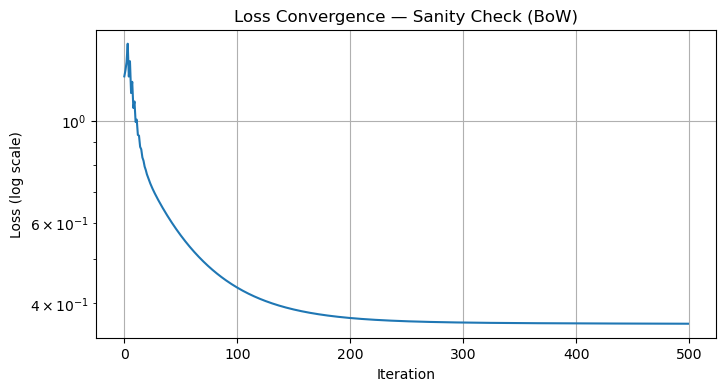

In [26]:
print('=== Sanity Check with BoW ===\n')

X_small = X_train_bow[:2000]
y_small = train_df['generated'].values[:2000].astype(float)

model_test = LogisticRegressionScratch(
    C=1.0,
    learning_rate=0.01,
    max_iter=500,
    tol=1e-8
)

model_test.fit(X_small, y_small)#פונקציית אימון מקבלת מטירצה דלילה ומערך תשובות y

y_pred_small = model_test.predict(X_small)
f1_small     = f1_score(y_small, y_pred_small)
print(f'F1 on subset: {f1_small:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(model_test.loss_history)
plt.yscale('log')
plt.title('Loss Convergence — Sanity Check (BoW)')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.grid(True)
plt.show()

<div dir="rtl" style="text-align: right;">

---
# חלק 6א — Grid Search + K-Fold Cross Validation (בונוס)

## הרעיון

### K-Fold Cross Validation

<p style="text-align: right;">
במקום לחלק את ה-train פעם אחת ל-train/validation, מחלקים ל-$K$ חלקים שווים ומריצים $K$ פעמים. בכל fold $k$:
</p>

<ul dir="rtl" style="text-align: right;">
    <li><b>Train:</b> כל החלקים חוץ מ-$k$</li>
    <li><b>Validation:</b> חלק $k$ בלבד</li>
</ul>

$$\text{score}_{\text{avg}} = \frac{1}{K} \sum_{k=1}^{K} \text{score}_k$$

### Grid Search

<p style="text-align: right;">
בדיקה שיטתית של <b>כל הפרמוטציות</b> — המכפלה הקרטזית של כל ערכי ה-hyperparameters. לכל פרמוטציה מריצים K-Fold ומחשבים ממוצע F1.
</p>

</div>

<div dir="rtl" style="text-align: right;">

## הגדרת הפרמוטציות

<p style="text-align: right;">
מגדירים את כל הערכים האפשריים לכל פרמטר. Grid Search יבדוק את כל המכפלה הקרטזית שלהם.
</p>

</div>

In [29]:
from sklearn.model_selection import ParameterGrid

# הגדרת כל הפרמוטציות לבדיקה
param_grid = {
    'C':             [0.1, 1.0, 10.0],      # חוזק הרגולריזציה
    'learning_rate': [0.001, 0.01, 0.1],    # קצב למידה
    'max_features':  [5000, 10000],          # גודל ה-vocabulary
}

# מכפלה קרטזית — כל הפרמוטציות האפשריות
all_params = list(ParameterGrid(param_grid))#עןושה רשימה של כל הקומבינציות 
print(f'Total combinations: {len(all_params)}')
print(f'Example: {all_params[0]}')

Total combinations: 18
Example: {'C': 0.1, 'learning_rate': 0.001, 'max_features': 5000}


<div dir="rtl" style="text-align: right;">

## הרצת Grid Search עם 5-Fold

</div>

In [31]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

X_train_text = train_df['clean_text'].values
y_train_all  = train_df['generated'].values.astype(float)

results = []

for i, params in enumerate(all_params):#ללולאה על הפרמוטציות 
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_text)):#מחזיר 5 זוגות של אינדקסים 

        # פיצול ל-train ו-validation של ה-fold
        X_fold_train_text = X_train_text[train_idx]
        X_fold_val_text   = X_train_text[val_idx]
        y_fold_train      = y_train_all[train_idx]
        y_fold_val        = y_train_all[val_idx]

        # בניית BoW לפי max_features של הפרמוטציה
        vec          = CountVectorizer(max_features=params['max_features'])#בניית ווקטור בגודל הפיצר שהגדרנו קודם
        X_fold_train = vec.fit_transform(X_fold_train_text)
        X_fold_val   = vec.transform(X_fold_val_text)

        # אימון
        model = LogisticRegressionScratch(
            C=params['C'],
            learning_rate=params['learning_rate'],
            max_iter=500,
            tol=1e-8
        )
        model.fit(X_fold_train, y_fold_train)

        # הערכה
        y_pred = model.predict(X_fold_val)
        score  = f1_score(y_fold_val, y_pred)
        fold_scores.append(score)

    mean_f1 = np.mean(fold_scores)
    std_f1  = np.std(fold_scores)#סטיית תקן
    results.append({**params, 'mean_f1': mean_f1, 'std_f1': std_f1})
    print(f'[{i+1}/{len(all_params)}] C={params["C"]} | lr={params["learning_rate"]} | max_features={params["max_features"]} | F1={mean_f1:.4f}')

# שמירת התוצאות מיד אחרי Grid Search
results_df = pd.DataFrame(results).sort_values('mean_f1', ascending=False).reset_index(drop=True)
best = results_df.iloc[0]
print(f'Best: C={best["C"]} | lr={best["learning_rate"]} | F1={best["mean_f1"]:.4f}')
print('\nGrid Search done ✓')

[1/18] C=0.1 | lr=0.001 | max_features=5000 | F1=0.8406
[2/18] C=0.1 | lr=0.001 | max_features=10000 | F1=0.8410
[3/18] C=0.1 | lr=0.01 | max_features=5000 | F1=0.5974
[4/18] C=0.1 | lr=0.01 | max_features=10000 | F1=0.7068
[5/18] C=0.1 | lr=0.1 | max_features=5000 | F1=0.5330
[6/18] C=0.1 | lr=0.1 | max_features=10000 | F1=0.5347
[7/18] C=1.0 | lr=0.001 | max_features=5000 | F1=0.8892
[8/18] C=1.0 | lr=0.001 | max_features=10000 | F1=0.8888
[9/18] C=1.0 | lr=0.01 | max_features=5000 | F1=0.9290
[10/18] C=1.0 | lr=0.01 | max_features=10000 | F1=0.9292
[11/18] C=1.0 | lr=0.1 | max_features=5000 | F1=0.5758
[12/18] C=1.0 | lr=0.1 | max_features=10000 | F1=0.7075
[13/18] C=10.0 | lr=0.001 | max_features=5000 | F1=0.8930
[14/18] C=10.0 | lr=0.001 | max_features=10000 | F1=0.8940
[15/18] C=10.0 | lr=0.01 | max_features=5000 | F1=0.9597
[16/18] C=10.0 | lr=0.01 | max_features=10000 | F1=0.9603
[17/18] C=10.0 | lr=0.1 | max_features=5000 | F1=0.9518
[18/18] C=10.0 | lr=0.1 | max_features=1000

<div dir="rtl" style="text-align: right;">

---
# חלק 6ג — התנסות ב-Hyperparameters (בונוס)

<p style="text-align: right;">
נתנסה בערכים שונים של hyperparameters של האלגוריתם:
</p>

| פרמטר | ערכים | השפעה |
|--------|--------|--------|
| `C` | 0.01, 0.1, 1, 10 | חוזק הרגולריזציה — $C$ גדול = פחות רגולריזציה |
| `learning_rate` | 0.1, 0.5, 1.0 | גודל הצעד ב-Gradient Descent |

</div>

=== 6ג — Hyperparameters Comparison ===

--- Effect of C (regularization) ---
  C=0.1   | Best F1=0.8410
  C=1.0   | Best F1=0.9292
  C=10.0  | Best F1=0.9603

--- Effect of learning_rate ---
  lr=0.001 | Best F1=0.8940
  lr=0.01  | Best F1=0.9603
  lr=0.1   | Best F1=0.9518


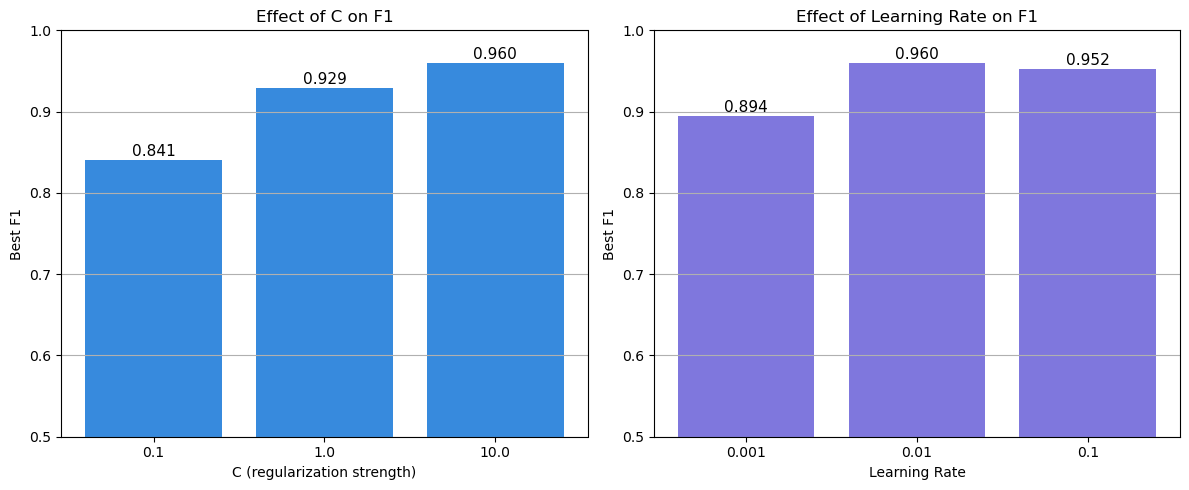

In [34]:
print('=== 6ג — Hyperparameters Comparison ===\n')

# השפעת C — לכל ערך C שולפים את ה-F1 הגבוה ביותר
print('--- Effect of C (regularization) ---') 
c_vals  = [0.1, 1.0, 10.0]  # שלושת ערכי C שבדקנו ב-Grid Search
f1_vals = []
for c in c_vals:
    best_f1 = results_df[results_df['C'] == c]['mean_f1'].max()  # הטוב ביותר מכל lr ו-max_features עבור C זה
    f1_vals.append(best_f1)  # שמירה לצורך הגרף
    print(f'  C={c:<5} | Best F1={best_f1:.4f}')

# השפעת learning_rate — לכל lr שולפים את ה-F1 הגבוה ביותר
print('\n--- Effect of learning_rate ---')
lr_vals = [0.001, 0.01, 0.1]  # שלושת ערכי lr שבדקנו
f1_lr   = []
for lr in lr_vals:
    best_f1 = results_df[results_df['learning_rate'] == lr]['mean_f1'].max()  # הטוב ביותר עבור lr זה
    f1_lr.append(best_f1)
    print(f'  lr={lr:<5} | Best F1={best_f1:.4f}')

# שני גרפים זה לצד זה — C משמאל, lr מימין
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# גרף 1 — השפעת C
ax1.bar([str(c) for c in c_vals], f1_vals, color='#378ADD')
ax1.set_xlabel('C (regularization strength)')
ax1.set_ylabel('Best F1')
ax1.set_title('Effect of C on F1')
ax1.set_ylim(0.5, 1.0)  # ציר Y מ-0.5 כדי להבליט הבדלים
ax1.grid(True, axis='y')
for i, v in enumerate(f1_vals):
    ax1.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11)  # ערך מעל כל עמודה

# גרף 2 — השפעת learning_rate
ax2.bar([str(lr) for lr in lr_vals], f1_lr, color='#7F77DD')
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('Best F1')
ax2.set_title('Effect of Learning Rate on F1')
ax2.set_ylim(0.5, 1.0)
ax2.grid(True, axis='y')
for i, v in enumerate(f1_lr):
    ax2.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11)  # ערך מעל כל עמודה

plt.tight_layout()  # מניעת חפיפה בין הגרפים
plt.show()

<div dir="rtl" style="text-align: right;">

---
# חלק 6ז — הצגת כל הניסויים (בונוס)

<p style="text-align: right;">
כל הפרמוטציות מוצגות ב-dataframe ממוין לפי F1 ממוצע.
</p>

</div>

In [36]:
# הצגת כל הפרמוטציות ממוינות
results_df = pd.DataFrame(results).sort_values('mean_f1', ascending=False).reset_index(drop=True)
display(results_df)

# עדכון הפרמוטציה הטובה ביותר
best = results_df.iloc[0]
print(f'\n=== Best combination ===')
print(f'C:             {best["C"]}')
print(f'Learning rate: {best["learning_rate"]}')
print(f'Max features:  {best["max_features"]}')
print(f'Mean F1:       {best["mean_f1"]:.4f} ± {best["std_f1"]:.4f}')

,C,learning_rate,max_features,mean_f1,std_f1
0,10.0,0.010,10000,0.960282,0.002936
1,10.0,0.010,5000,0.959705,0.002345
2,10.0,0.100,5000,0.951832,0.005909
3,10.0,0.100,10000,0.949289,0.007906
4,1.0,0.010,10000,0.929189,0.003261
5,1.0,0.010,5000,0.928976,0.003233
6,10.0,0.001,10000,0.893987,0.002204
7,10.0,0.001,5000,0.892991,0.004816
8,1.0,0.001,5000,0.889223,0.004525
9,1.0,0.001,10000,0.888808,0.002011



=== Best combination ===
C:             10.0
Learning rate: 0.01
Max features:  10000.0
Mean F1:       0.9603 ± 0.0029


<div dir="rtl" style="text-align: right;">

### הפרמוטציה הטובה ביותר

</div>

<div dir="rtl" style="text-align: right;">

---
# חלק 4 — אימון סופי על כל ה-Train

<p style="text-align: right;">
לאחר שמצאנו את הקומבינציה הטובה ביותר דרך Grid Search + K-Fold, מאמנים מחדש על <b>כל</b> ה-trainset עם הפרמטרים האלה. למה לאמן מחדש? כי במהלך ה-K-Fold השתמשנו בחלק מה-train לvalidation — עכשיו נשתמש בכולו.
</p>

</div>

Training final model on all train data...
First loss: 0.8007
Last loss:  0.2249


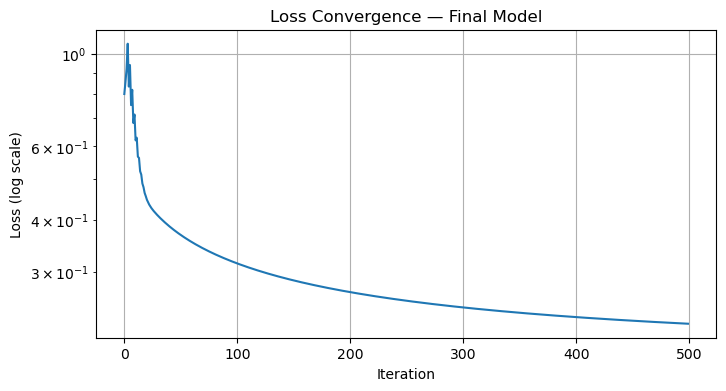

In [39]:
# בניית ה-vectorizer הסופי עם הפרמטרים הטובים ביותר
final_vec = CountVectorizer(max_features=int(best['max_features']))
X_train_final = final_vec.fit_transform(train_df['clean_text'])
X_test_final  = final_vec.transform(test_df['clean_text'])
y_train_final = train_df['generated'].values.astype(float)

# אימון סופי על כל ה-train
print('Training final model on all train data...')
final_model = LogisticRegressionScratch(
    C=best['C'],
    learning_rate=best['learning_rate'],
    max_iter=500,
    tol=1e-8
)
final_model.fit(X_train_final, y_train_final)

print(f'First loss: {final_model.loss_history[0]:.4f}')
print(f'Last loss:  {final_model.loss_history[-1]:.4f}')

# גרף התכנסות
plt.figure(figsize=(8, 4))
plt.plot(final_model.loss_history)
plt.yscale('log')
plt.title('Loss Convergence — Final Model')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.grid(True)
plt.show()

<div dir="rtl" style="text-align: right;">

### הצגת תהליך Feature Engineering על 2-3 דוגמאות מה-train

</div>

In [41]:
# הצגת תהליך החיזוי על 3 דוגמאות מה-train
print('=== Examples from Train ===\n')
for i in range(3):
    row   = train_df.iloc[i]
    label = 'AI' if row['generated'] == 1.0 else 'Human'
    prob  = final_model.predict_proba(X_train_final[i])[0]
    pred  = 'AI' if prob >= 0.5 else 'Human'

    print(f'[{i+1}] True label: {label} | Predicted: {pred} | P(AI): {prob:.3f}')
    print(f'     Text: "{row["clean_text"][:120]}..."')
    print()

=== Examples from Train ===

[1] True label: AI | Predicted: AI | P(AI): 0.805
     Text: "i agree with the principals decision that all students should participate in at least one extracurricular activity there..."

[2] True label: Human | Predicted: Human | P(AI): 0.004
     Text: "many schools assign summer projects as a way to ensure that students continue learning throughout summer break it would ..."

[3] True label: Human | Predicted: Human | P(AI): 0.237
     Text: "studying a plane called venus is worthy pursuit buq iq is dangerous as we have seen in the paragraph exploring venus can..."



<div dir="rtl" style="text-align: right;">

---
# חלק 5 — חיזוי ושערוך איכות על ה-Test

<p style="text-align: right;">
ה-testset לא נגע לאורך כל תהליך האימון — הוא שמור לבדיקה סופית בלבד. <b>חשוב:</b> מפעילים על ה-test את <u>אותו</u> preprocessing שהפעלנו על ה-train.
</p>

### 5 חיזויים ראשונים על ה-test

</div>

In [43]:
# חיזוי על כל ה-test
y_test      = test_df['generated'].values.astype(float)
y_pred_test = final_model.predict(X_test_final)
y_prob_test = final_model.predict_proba(X_test_final)

# 5 חיזויים ראשונים
print('=== First 5 predictions on test ===\n')
for i in range(5):
    row   = test_df.iloc[i]
    true  = 'AI' if y_test[i] == 1.0 else 'Human'
    pred  = 'AI' if y_pred_test[i] == 1 else 'Human'
    prob  = y_prob_test[i]
    check = '✓' if true == pred else '✗'

    print(f'[{i+1}] {check} True: {true} | Predicted: {pred} | P(AI): {prob:.3f}')
    print(f'     Text: "{row["clean_text"][:120]}..."')
    print()

=== First 5 predictions on test ===

[1] ✓ True: Human | Predicted: Human | P(AI): 0.099
     Text: "our system of driving has been implemented for an along time now driverless cars would be a huge leap in technology ther..."

[2] ✓ True: Human | Predicted: Human | P(AI): 0.105
     Text: "you should be a seagoing cowboy what are seagoing cowboyr seagoing cowboyr are the people that take care of animal that ..."

[3] ✓ True: AI | Predicted: AI | P(AI): 0.930
     Text: "hey there so you want me to write about the pros anh cons of aiming high vs aiming low in life well i guess i can give i..."

[4] ✓ True: Human | Predicted: Human | P(AI): 0.009
     Text: "dear principal i really think of should go with policy one becafse kids in school will start to take them oft anyway and..."

[5] ✓ True: Human | Predicted: Human | P(AI): 0.317
     Text: "injuries occur each year from accidents caused by texting while driving out of every car accidents in the united states ..."



<div dir="rtl" style="text-align: right;">

### מדד האיכות — F1 על ה-test

</div>

=== Final F1 Score on Test: 0.9641 ===

Classification Report:
              precision    recall  f1-score   support

       Human       0.95      0.98      0.97      5000
          AI       0.98      0.95      0.96      5000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



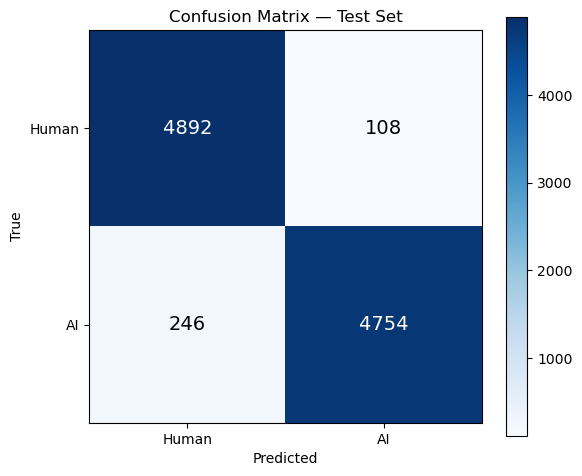

In [45]:
# מדד F1 סופי
f1 = f1_score(y_test, y_pred_test)
print(f'=== Final F1 Score on Test: {f1:.4f} ===\n')
print('Classification Report:')
print(classification_report(y_test, y_pred_test, target_names=['Human', 'AI']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Human', 'AI'])
ax.set_yticklabels(['Human', 'AI'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=14, color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

# חלק 6ד — Imbalanced Data (בונוס)

<p style="text-align: right;">
הדאטאסט המקורי לא מאוזן: <b>62.8% אנושי</b> ו-<b>37.2% AI</b>. חוסר איזון עלול לגרום למודל להטות לעבר המחלקה הגדולה ולפספס טקסטי AI. נשווה בין שתי גישות:
</p>

<ul dir="rtl" style="text-align: right;">
    <li>
        <b>שיטה 1 — Under-sampling:</b> לקחנו 25,000 דוגמאות מכל מחלקה — איזון מלא.
        $$N'_{\text{human}} = N_{\text{AI}} = 25{,}000$$
        <b>יתרון:</b> פשוט ומהיר. <b>חיסרון:</b> מאבדים 280K דוגמאות אנושיות.
    </li>
    <li>
        <b>שיטה 2 — ללא sampling:</b> דגמנו 50,000 שורות אקראיות מהדאטה המקורי — עם חוסר האיזון המקורי (62/38). כך בדקנו מה קורה כשלא מטפלים בבעיה.
    </li>
</ul>

<p style="text-align: right;">
<b>הערה:</b> שיטה נוספת שקיימת היא <b>SMOTE</b> — יצירת דוגמאות סינטטיות חדשות על ידי אינטרפולציה בין דוגמאות קרובות:
$$x_{\text{new}} = x_i + \lambda \cdot (x_{\text{neighbor}} - x_i), \quad \lambda \in [0,1]$$
לא יישמנו אותה כי היא מורכבת יותר ולא תמיד עובדת טוב עם טקסט.
</p>

</div>

=== 6ד — Imbalanced Data ===

Original dataset distribution:
  Human: 305797 (62.8%)
  AI:    181438 (37.2%)

Method 1 — Under-sampling (balanced 25K each):
  Already done — F1=0.9641

Method 2 — No sampling (imbalanced):
  F1=0.9479

=== Comparison ===
  Under-sampling (balanced): F1=0.9641
  No sampling (imbalanced):  F1=0.9479


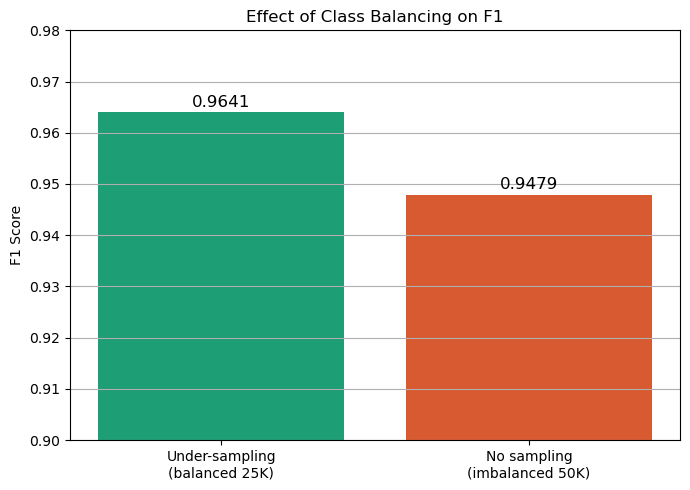

In [47]:
# שאלה מרכזית: האם חוסר האיזון בדאטה פוגע בביצועים?
# הדאטה המקורי מכיל 62.8% אנושי ורק 37.2% AI —
# מודל שלא מטפל בזה עלול ללמוד להטות לעבר המחלקה הגדולה
print('=== 6ד — Imbalanced Data ===\n')

# הצגת התפלגות המחלקות בדאטה המקורי לפני כל טיפול
print(f'Original dataset distribution:')
print(f'  Human: {(df_full["generated"]==0).sum()} ({(df_full["generated"]==0).mean()*100:.1f}%)')
print(f'  AI:    {(df_full["generated"]==1).sum()} ({(df_full["generated"]==1).mean()*100:.1f}%)')

# שיטה 1 — Under-sampling: לקחנו 25K מכל מחלקה בתחילת המטלה
# התוצאה כבר קיימת מהאימון הסופי בחלק 4
print(f'\nMethod 1 — Under-sampling (balanced 25K each):')
print(f'  Already done — F1={f1_score(y_test, y_pred_test):.4f}')

# שיטה 2 — ללא sampling: נדגום 50K שורות אקראיות עם חוסר האיזון המקורי
# כך נבדוק מה קורה כשלא מטפלים בבעיה — הדאטה יהיה ~62% Human, 38% AI
print(f'\nMethod 2 — No sampling (imbalanced):')

# דגימה אקראית של 50K שורות מהדאטה המקורי הלא מאוזן
df_imbalanced = df_full.sample(50000, random_state=42)

# פיצול train/test — אותו יחס 80/20 כמו קודם
train_imb, test_imb = train_test_split(df_imbalanced, test_size=0.2, random_state=42)

# copy כדי למנוע SettingWithCopyWarning בעת הוספת עמודת clean_text
train_imb = train_imb.copy()
test_imb  = test_imb.copy()

# אותו ניקוי טקסט שעשינו על הדאטה המאוזן
train_imb['clean_text'] = train_imb['text'].apply(clean_text)
test_imb['clean_text']  = test_imb['text'].apply(clean_text)

# בניית BoW — fit רק על train, transform על שניהם
# vocabulary נלמד מה-train בלבד כדי למנוע data leakage
vec_imb  = CountVectorizer(max_features=10000)
X_tr_imb = vec_imb.fit_transform(train_imb['clean_text'])
X_te_imb = vec_imb.transform(test_imb['clean_text'])

# המרת תוויות ל-float לצורך חישובים מתמטיים במודל
y_tr_imb = train_imb['generated'].values.astype(float)
y_te_imb = test_imb['generated'].values.astype(float)

# אותם פרמטרים אופטימליים — רק הדאטה משתנה
# כך ההשוואה הוגנת — רק השפעת האיזון נמדדת
model_imb = LogisticRegressionScratch(C=10.0, learning_rate=0.01, max_iter=500, tol=1e-8)
model_imb.fit(X_tr_imb, y_tr_imb)

# חיזוי וחישוב F1 על ה-test הלא מאוזן
y_pred_imb = model_imb.predict(X_te_imb)
f1_imb     = f1_score(y_te_imb, y_pred_imb)
print(f'  F1={f1_imb:.4f}')

# השוואה סופית בין שתי הגישות
print(f'\n=== Comparison ===')
print(f'  Under-sampling (balanced): F1={f1_score(y_test, y_pred_test):.4f}')
print(f'  No sampling (imbalanced):  F1={f1_imb:.4f}')

# גרף השוואה — ירוק=מאוזן (טוב יותר), אדום=לא מאוזן
# ציר Y מתחיל מ-0.9 כדי להבליט את ההפרש
methods = ['Under-sampling\n(balanced 25K)', 'No sampling\n(imbalanced 50K)']
scores  = [f1_score(y_test, y_pred_test), f1_imb]
colors  = ['#1D9E75', '#D85A30']

plt.figure(figsize=(7, 5))
plt.bar(methods, scores, color=colors)
plt.ylabel('F1 Score')
plt.title('Effect of Class Balancing on F1')
plt.ylim(0.9, 0.98)
plt.grid(True, axis='y')

# הצגת הערך המדויק מעל כל עמודה
for i, v in enumerate(scores):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()
#משמעות תוצאות 162 דוגמאות שסווגו שגוי עבור דאטה לא מאוזן 

<div dir="rtl" style="text-align: right;">

---
# חלק 6ו — Explainability (בונוס)

## מילים שמסגירות AI מול אנושי

<p style="text-align: right;">
ב-Logistic Regression, כל feature (מילה) מקבל <b>מקדם</b> (coefficient) $w_j$:
</p>

$$z = \sum_{j=1}^{D} w_j \cdot x_j + b$$

<ul dir="rtl" style="text-align: right;">
    <li><b>$w_j > 0$ גדול:</b> המילה $j$ מגדילה את ההסתברות ל-AI.</li>
    <li><b>$w_j < 0$ קטן:</b> המילה $j$ מגדילה את ההסתברות לאנושי.</li>
</ul>

<p style="text-align: right;">
ציפייה: AI ישתמש במילים פורמליות כמו <code>furthermore</code>, <code>however</code>, <code>delve</code>.
בני אדם ישתמשו בשפה ספונטנית כמו <code>kinda</code>, <code>tbh</code>, <code>gonna</code>.
</p>

</div>

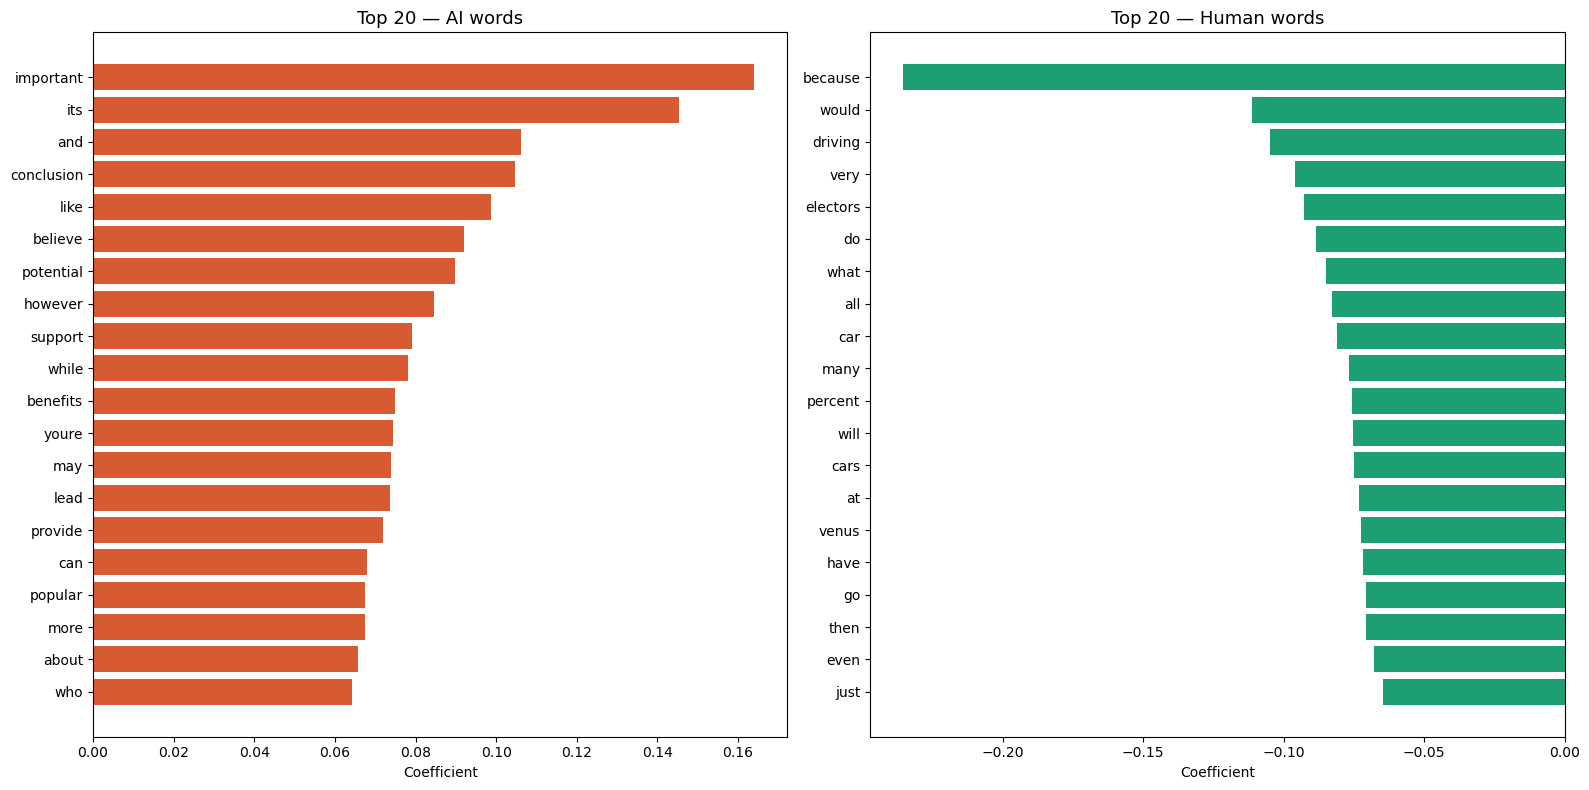

=== Top 10 AI words ===
  important            coef=0.164
  its                  coef=0.145
  and                  coef=0.106
  conclusion           coef=0.105
  like                 coef=0.099
  believe              coef=0.092
  potential            coef=0.090
  however              coef=0.084
  support              coef=0.079
  while                coef=0.078

=== Top 10 Human words ===
  because              coef=-0.235
  would                coef=-0.111
  driving              coef=-0.105
  very                 coef=-0.096
  electors             coef=-0.093
  do                   coef=-0.089
  what                 coef=-0.085
  all                  coef=-0.083
  car                  coef=-0.081
  many                 coef=-0.077


In [49]:
# שליפת המקדמים של המודל
feature_names = final_vec.get_feature_names_out()
coefs = final_model.weights

n_top = 20

# 20 המילים שהכי מזהות AI (מקדם חיובי גבוה)
top_ai_idx    = coefs.argsort()[-n_top:][::-1]
# 20 המילים שהכי מזהות אנושי (מקדם שלילי נמוך)
top_human_idx = coefs.argsort()[:n_top]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# גרף מילות AI
ax1.barh(feature_names[top_ai_idx], coefs[top_ai_idx], color='#D85A30')
ax1.set_title('Top 20 — AI words', fontsize=13)
ax1.set_xlabel('Coefficient')
ax1.invert_yaxis()

# גרף מילות אנושי
ax2.barh(feature_names[top_human_idx], coefs[top_human_idx], color='#1D9E75')
ax2.set_title('Top 20 — Human words', fontsize=13)
ax2.set_xlabel('Coefficient')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# הדפסת המילים
print('=== Top 10 AI words ===')
for idx in top_ai_idx[:10]:
    print(f'  {feature_names[idx]:<20} coef={coefs[idx]:.3f}')

print('\n=== Top 10 Human words ===')
for idx in top_human_idx[:10]:
    print(f'  {feature_names[idx]:<20} coef={coefs[idx]:.3f}')

<div dir="rtl" style="text-align: right; line-height: 1.6;">

#  מסקנות הפרויקט ותוצאות

<hr>

### 📈 1. ביצועי המודל האופטימלי
<p style="text-align: right;">
המודל הגיע לתוצאה גבוהה מאוד עבור מימוש מאפס של <code>Logistic Regression</code> בשילוב עם מייצג <code>Bag of Words</code> פשוט. הדבר מראה שהבעיה של זיהוי טקסט AI ניתנת לפתרון יעיל ומדויק גם ללא מודלים מורכבים ורשתות עמוקות.
</p>

<ul dir="rtl" style="text-align: right;">
    <li><b>מדד F1-Score על ה-Test Set (מחלקת AI):</b> <span style="color: #2563eb; font-weight: bold; font-size: 1.1em;">0.9641</span></li>
</ul>

---

### 📊 2. Feature Engineering — BoW עדיף על TF-IDF
<p style="text-align: right;">
הממצא המפתיע ביותר בפרויקט הוא שגישת ה-<b>Bag of Words (BoW)</b> עם ערך F1 של <code>0.960</code>, ניצחה את גישת ה-<b>TF-IDF</b> אשר הגיעה לציון F1 של <code>0.815</code> בלבד — פער משמעותי ביותר.
</p>

<p style="text-align: right;">
<b>הסיבה הנומרית:</b> אלגוריתם ה-TF-IDF מייצר ערכים קטנים ומנורמלים, המקשים על תהליך האופטימיזציה של ה-<code>Gradient Descent</code> שמימשנו מאפס לצבור תנופה וללמוד בצורה אפקטיבית. לעומת זאת, שיטת ה-BoW מתבססת על ספירות שלמות (Integers) שנותנות גרדיאנטים גדולים ויציבים יותר, מה שמוביל ללמידה ולהתכנסות מהירה בהרבה.
</p>

---

### ⚙️ 3. השפעת היפר-פרמטרים (Hyperparameters)
<p style="text-align: right;">
במהלך שלב כוונון הפרמטרים, נבחנו מספר קומבינציות שהעלו תובנות קריטיות על התנהגות המודל:
</p>

<ul dir="rtl" style="text-align: right;">
    <li><code>C = 10.0</code> — <b>רגולריזציה חלשה עובדת הכי טוב.</b> המודל זקוק לחופש פעולה מתמטי כדי ללמוד את ההבדלים הדקים והניואנסים הסגנוניים שבין כתיבת AI לכתיבה אנושית.</li>
    <li><code>learning_rate = 0.01</code> — נמצא כאיזון המדויק והאופטימלי בין מהירות ההתכנסות לבין שמירה על יציבות נומרית לאורך האיטרציות.</li>
    <li><code>C = 0.1</code> עם <code>lr = 0.1</code> — <b>השילוב הגרוע ביותר (F1 = 0.53).</b> הפעלת רגולריזציה חזקה מדי יחד עם צעד למידה (Learning Rate) גדול מדי גרמו לקריסת יכולת הלימוד של המודל ולחוסר התכנסות.</li>
</ul>

---

### ⚖️ 4. התמודדות עם דאטאסט לא מאוזן (Imbalanced Data)
<p style="text-align: right;">
איזון הדאטאסט באמצעות טכניקת תת-דגימה (<b>Under-sampling</b>) לכלל של 25,000 דוגמאות מכל מחלקה, שיפר את מדד ה-F1 ב-<b>1.6%</b> בהשוואה לעבודה עם הדאטאסט המקורי הלא מאוזן. 
</p>
<p style="text-align: right;">
במונחים מעשיים, מתוך מדגם של 10,000 טקסטים, מדובר על <b>162 טקסטים נוספים שסווגו בצורה נכונה</b> — שיפור משמעותי ובעל ערך רב במערכות פרודקשן בעולם האמיתי.
</p>

---

### 🔍 5. Explainability (הסבירות המודל) — מה מאפיין כל סגנון?
<p style="text-align: right;">
המשקולות שנלמדו במודל הלוגיסטי חשפו דפוסים מובהקים וברורים המאפיינים כל אחד ממקורות הטקסט:
</p>

<table dir="rtl" style="margin: 20px auto; border-collapse: collapse; width: 80%; text-align: center; border: 1px solid #e2e8f0;">
    <thead>
        <tr style="background-color: #f1f5f9;">
            <th style="padding: 10px; border: 1px solid #e2e8f0;">מילים המאפיינות AI (🤖)</th>
            <th style="padding: 10px; border: 1px solid #e2e8f0;">מילים המאפיינות בני אדם (✍️)</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px; border: 1px solid #e2e8f0;"><code>important</code>, <code>conclusion</code>, <code>however</code>, <code>benefits</code>, <code>potential</code></td>
            <td style="padding: 8px; border: 1px solid #e2e8f0;"><code>because</code>, <code>would</code>, <code>very</code>, <code>just</code>, <code>do</code></td>
        </tr>
    </tbody>
</table>

<p style="text-align: right;">
<b>ניתוח תיאורטי:</b> הממצאים הללו מתכתבים בצורה מלאה עם הספרות המקצועית — מודלי AI נוטים להשתמש במבנים רשמיים, מילות קישור אקדמיות ושפה מובנית, בעוד שבני אדם כותבים בצורה ספונטנית, ישירה ויומיומית יותר.
</p>

---

### 📉 6. יציבות המודל ומגבלותיו
<p style="text-align: right;">
במסגרת תהליך התיקוף הצולב (<b>K-Fold Cross-Validation</b>), סטיית התקן של מדדי ה-F1 בין הקיפולים השונים עמדה על <b>0.0029</b> בלבד. נתון נמוך זה מעיד על כך שהמודל שפיתחנו יציב מאוד ואינו תלוי בחלוקה מקרית של הנתונים.
</p>

<p style="text-align: right;">
<b>מגבלות הפרויקט וכיווני המשך:</b>
</p>
<ul dir="rtl" style="text-align: right;">
    <li><b>גודל המדגם:</b> עבדנו על תת-מדגם של 50,000 שורות מתוך כ-487,000 שורות קיימות בדאטאסט. אימון המודל על הדאטאסט המלא יכול לשפר את הדיוק וההכללה שלו.</li>
    <li><b>הקשר סמנטי:</b> מודל Bag of Words לא מביא בחשבון את סדר המילים. מודל שמבין הקשר סמנטי רחב (כמו BERT) יגיע לתוצאות גבוהות יותר.</li>
    <li><b>מגבלות האופטימיזציה:</b> שיטת ה-TF-IDF לא תפקדה היטב בשילוב עם ה-Gradient Descent שמומש מאפס. פתרון אפשרי לאתגר זה בעתיד הוא שימוש ב-Solver אנליטי.</li>
</ul>

</div>